# Introduction & Setup

We begin by importing all the necessary **libraries and functions** required for the project, along with the three selected **machine learning models**:

* **Random Forest**
* **Multi-Layer Perceptron (MLP)**
* **LightGBM**

In this phase, we also define the **path constants** that will be used throughout the workflow.


In [3]:
# Import common functions and utilities defined in the "utilities" module
from utilities_and_libraries import utilities as utl
import numpy as np

# Import the three classification models chosen for the project
from models.first_classifier import random_forest_model   # Random Forest
from models.second_classifier import mlp_model            # Multi-Layer Perceptron (neural network)
from models.third_classifier import lightgbm_model        # LightGBM (gradient boosting)

# Define the main dataset path
dataset_path = "dataset"

The dataset containing **only Win64** samples is then **downloaded**.
This step can be skipped if the dataset has already been retrieved, as the downloading process is relatively time-consuming.


In [ ]:
utl.dataset_download(dataset_path)

The dataset is composed of:
* **training files**
* **test files**
* **challenge files**

Since the challenge set **contains not only Win64 samples** but also other PE files, **it must be cleaned** to ensure that the evaluation focuses **exclusively on Win64 executables**.


In [ ]:
utl.clean_challenge_non_win64(dataset_path)

# Dataset analysis & Normalization

Let's perform an initial analysis of the dataset:

In [3]:
utl.count_files_and_rows(dataset_path)

train: 52 file, 1040000 righe
test: 12 file, 240000 righe
challenge: 64 file, 814 righe


We can see that there are **52 training files**, with a total of **1,040,000 samples** (both malicious and benign).
For the **test set**, there are **12 files** with **240,000 samples**, and for the **challenge set**, there are **64 files** with **814 samples**.

Thus, the dataset is divided as follows:
* **Train:** 80.9%
* **Test:** 18.7%
* **Challenge:** 0.5%


Let's see how the labels are distributed:

In [4]:
utl.count_labels(dataset_path)

train: benign=520000, malicious=520000
challenge: benign=0, malicious=814
test: benign=120000, malicious=120000


We can see that the training and test data are split exactly **50/50**, while the challenge data contain only **malicious** samples.

Let's display the attributes of each sample:

In [5]:
utl.print_features(dataset_path)

['md5', 'sha1', 'sha256', 'tlsh', 'first_submission_date', 'last_analysis_date', 'detection_ratio', 'label', 'file_type', 'family', 'family_confidence', 'behavior', 'file_property', 'packer', 'exploit', 'group', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories', 'richheader', 'authenticode', 'pefilewarnings', 'week_id', 'caps', 'ttps', 'mbc']


The main ones are:
* Hashes (md5, sha1, sha256, tlsh) → unique and similarity identifiers
*  Metadata → submission dates, detection ratio, file type, family
*  Static features → PE structure (header, sections, imports, exports, entropy, strings)
*  Behavioral info → actions, packers, exploits, capabilities, and MITRE ATT&CK (TTPs)
*  Label → 0 = benign, 1 = malicious

Since many sample attributes are not numeric, **EMBER** provides functions to vectorize them using **thrember**.

In [ ]:
utl.vectorize_dataset(dataset_path)

Once vectorized and saved, we can load them into the current runtime:

In [4]:
x_train, y_train, x_test, y_test, x_chal, y_chal = utl.load_vectorized_datasets(dataset_path)

Let's analyze the **maximum**, **minimum**, and **mean** values of this vectorized data:

In [3]:
print("Min:", np.min(x_train))
print("Max:", np.max(x_train))
print("Mean:", np.mean(x_train))

Min: -54964433000000.0
Max: 1.8446744e+19
Mean: 1136828700000.0


I notice that some values are extremely large, while others are extremely small.
To observe a more meaningful distribution, we apply two scaling methods:

* **Log-scaling** reduces the impact of extreme values by compressing large numeric ranges while preserving their sign.
* **Standard scaling** normalizes each feature (mean = 0, std = 1) to ensure that all variables contribute equally to the model.


In [7]:
# === Log-transform (with sign) ===
x_train_log = np.sign(x_train) * np.log1p(np.abs(x_train))
x_test_log  = np.sign(x_test)  * np.log1p(np.abs(x_test))
x_chal_log  = np.sign(x_chal)  * np.log1p(np.abs(x_chal))

# === Standard scaling ===
scaler = utl.StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_log)
x_test_scaled  = scaler.transform(x_test_log)
x_chal_scaled  = scaler.transform(x_chal_log)

I limit the values to a range of ±5 due to the presence of large outliers.


In [8]:
x_train_scaled = np.clip(x_train_scaled, -5, 5)
x_test_scaled  = np.clip(x_test_scaled,  -5, 5)
#x_chal_scaled  = np.clip(x_chal_scaled,  -5, 5)  for the challange I prefer to not remove them

Now that we have vectorized and normalized the data, let's start comparing the **mean feature distributions** of benign and malicious samples across the train and test sets to identify differences or shifts that could affect the model’s generalization.

#### Train Benign vs Train Malicious
Compares benign and malicious samples **within the training set**.

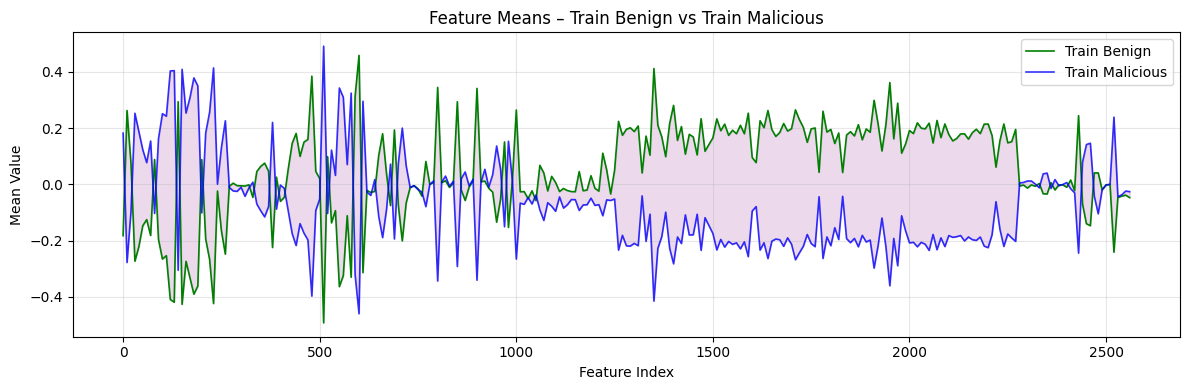

In [6]:
utl.plot_feature_comparison(x_train_scaled, y_train, x_train_scaled, y_train,
                        label1_type='benign', label2_type='malicious',
                        name1='Train', name2='Train')

- The curves show clear differences, especially across the first ~1000 features.
- Indicates the presence of **discriminative features** in the training data, which help the model learn effectively.

#### Test Benign vs Test Malicious
Compares benign and malicious samples **within the test set**.

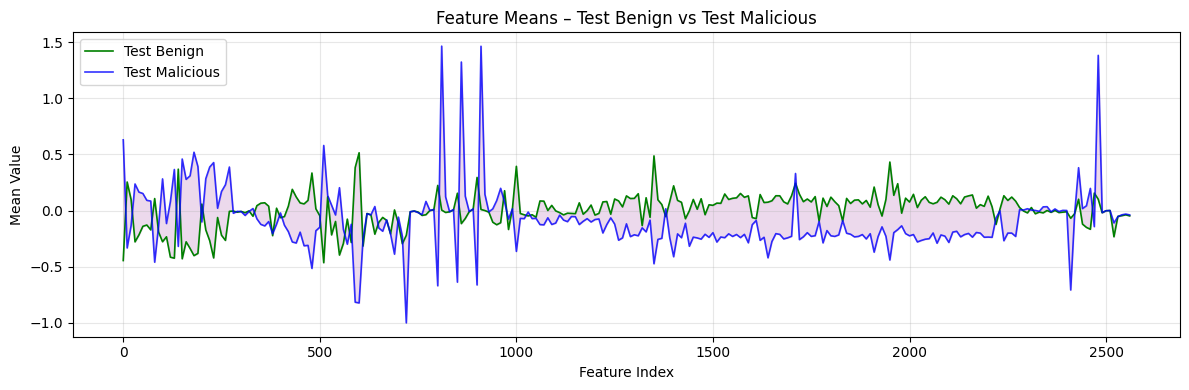

In [7]:
utl.plot_feature_comparison(x_test_scaled, y_test, x_test_scaled, y_test,
                        label1_type='benign', label2_type='malicious',
                        name1='Test', name2='Test')

- Differences are **less pronounced** and noisier.
- The two groups appear more similar → the model may face **greater generalization difficulty**.
- Sharp spikes (around features 800–1000) could represent **outliers** or unseen patterns.

#### Train Benign vs Test Benign
Compares benign samples between train and test sets.

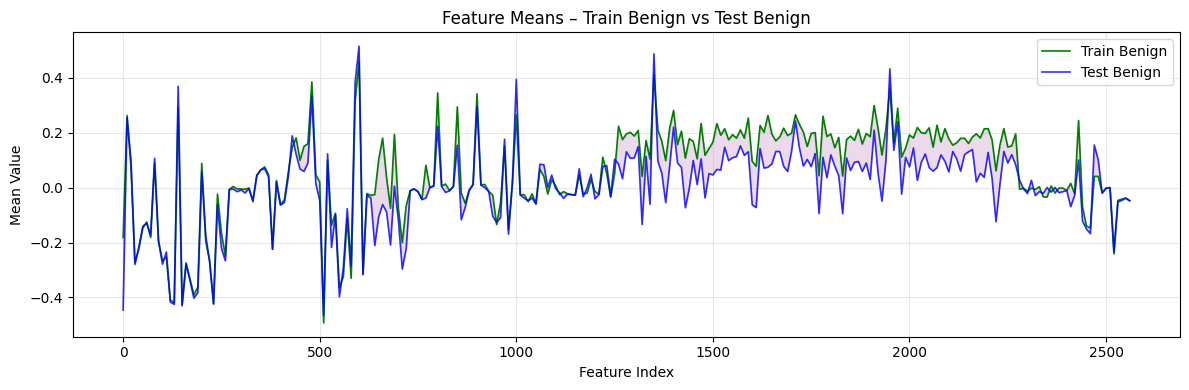

In [8]:
utl.plot_feature_comparison(x_train_scaled, y_train, x_test_scaled, y_test,
                        label1_type='benign', label2_type='benign',
                        name1='Train', name2='Test')

- The curves are **very similar**, showing consistent distribution.
- Minor variations are due to sampling.
- Suggests **good generalization** for the benign class.

#### Train Malicious vs Test Malicious
Compares malicious samples between train and test sets.

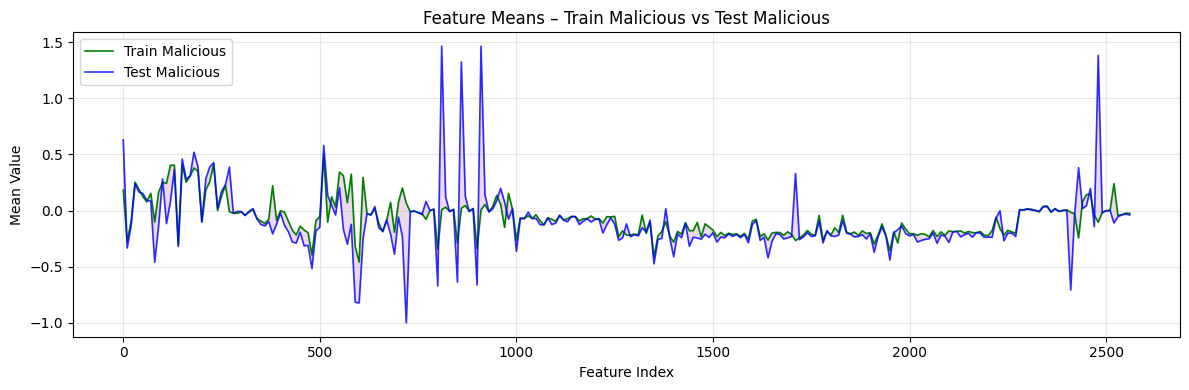

In [9]:
utl.plot_feature_comparison(x_train_scaled, y_train, x_test_scaled, y_test,
                        label1_type='malicious', label2_type='malicious',
                        name1='Train', name2='Test')

- The curves are mostly aligned, with **slight deviations** around features ~800–1000 and >2000.
- Indicates a **partial distribution shift** in the malicious data between sets.
- This could explain a **performance drop** on test or challenge data due to **domain shift**.

# Model training & Accuracy analysis

For this task, I choose 3 models:

LightGBM – A fast and efficient gradient boosting model, well-suited for large datasets.

Random Forest – An ensemble of decision trees that improves generalization and robustness.

MLP (Multi-Layer Perceptron) – A neural network model used to capture complex, non-linear relationships in the data.

Let's train them:

In [ ]:
models = {
    "LightGBM": lightgbm_model,
    "Random Forest": random_forest_model,
    "MLP": mlp_model
}
trained_models = utl.train_and_plot_times(models, x_train_scaled, y_train,"/models/saved_models")

Let's evaluate how well these models perform on the test data:

In [ ]:
accuracies= utl.evaluate_accuracy(trained_models, x_test_scaled, y_test)

We can see that the training was successful for all three models, reaching a very high accuracy.

Let's save them so they can be retrieved whenever needed.

In [ ]:
utl.save_models(trained_models)

(Alternatively, let's load them if they have already been saved.)

In [9]:
trained_models = utl.load_models("models/saved_models")

✅ Models loaded: LightGBM, MLP, Random_Forest


# Challange samples

Now let's test the models with the challenges, but first let's see the differences between train and challange samples:

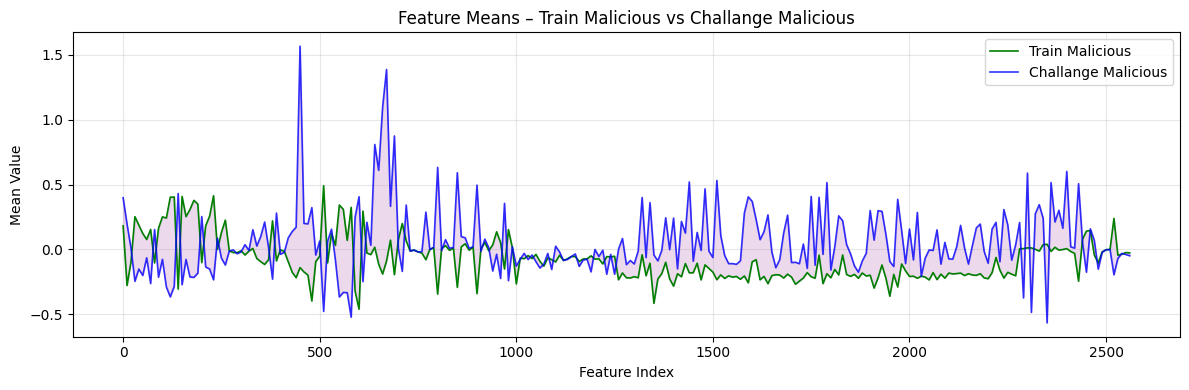

In [10]:
utl.plot_feature_comparison(x_train_scaled, y_train, x_chal_scaled, y_chal,
                        label1_type='malicious', label2_type='malicious',
                        name1='Train', name2='Challange')

- The curves show **noticeable differences**, especially across the first ~1000 features.
- The challenge data exhibits higher variability and amplitude peaks, suggesting **different statistical properties** or **novel feature behaviors** not present in training.
- Indicates a **strong domain shift** for malicious samples, which can significantly affect model performance and detection reliability.


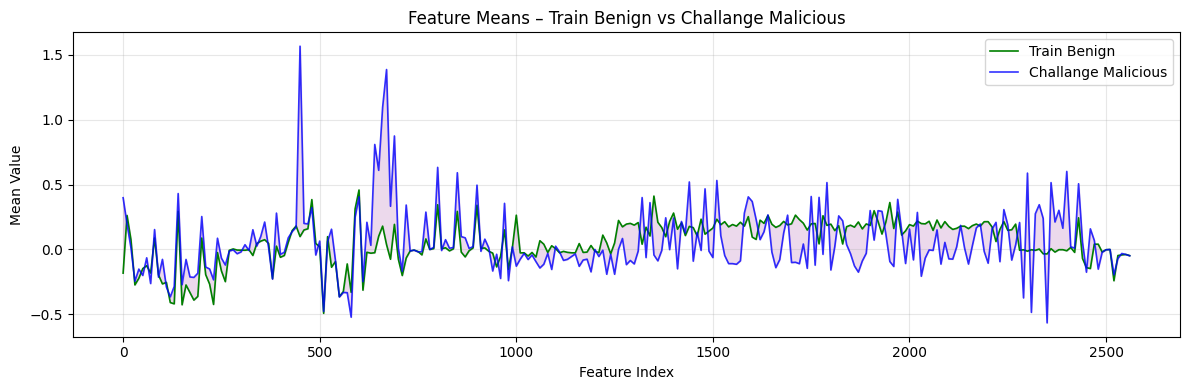

In [11]:
utl.plot_feature_comparison(x_train_scaled, y_train, x_chal_scaled, y_chal,
                        label1_type='benign', label2_type='malicious',
                        name1='Train', name2='Challange')

- The mean feature profiles differ substantially, with challenge malware showing **larger oscillations** and outliers.
- Highlights that challenge malware samples deviate both from benign and from previously seen malicious data.
- Suggests that the challenge set introduces **new malware patterns** outside the training distribution, making them **harder to detect**.

Now let's see how well/bad the models behave:

📊 Model accuracies:
LightGBM: 0.8907
MLP: 0.4300
Random_Forest: 0.4189


C:\Users\ropin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


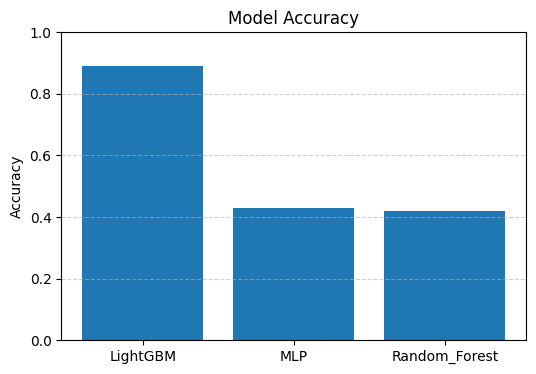

In [13]:
faccuracies= utl.evaluate_accuracy(trained_models, x_chal_scaled, y_chal)